In [ ]:
from qiskit_ibm_runtime import QiskitRuntimeService
import numpy as np
import matplotlib.pyplot as plt
from qiskit_device_benchmarking.bench_code.mrb import MirrorQA, QuantumAwesomeness
import os, random

# Fix random seed for numpy
SEED = 123 # pick your favorite int
os.environ["PYTHONHASHSEED"] = str(SEED)  # optional, for hash-based determinism
random.seed(SEED)
np.random.seed(SEED)

QiskitRuntimeService.save_account(
    token="", # Your token is confidential.
    instance="", # Optionally specify the instance to use.
    name="", # Optionally name this set of account credentials.
    set_as_default=True, # Optionally set these as your default credentials.
    overwrite=True   
)

service = QiskitRuntimeService()
backend = service.backend("ibm_fez")

In [2]:
# Define parameters for the simulated backend
num_qubits = 156
shots = 10000
lengths = [2]+[4,10,20,50,100]
num_samples = 20

# Set up the experiment object
exp = MirrorQA(
    range(num_qubits),
    lengths=lengths,
    backend=backend,
    two_qubit_gate_density=0.25,
    num_samples=num_samples,
    initial_entangling_angle=np.pi/2, seed=SEED
)

# Set run options
exp.set_run_options(shots=shots)

# Run the experiment with timing
rb_data = exp.run()
print("Job IDs:", rb_data.job_ids)

Job IDs: ['d4do2j9eg65s738lmf70']


In [3]:
import os
import json
import qiskit
import qiskit.qasm2

# Get the job id
job_id = rb_data.job_ids[0]

# Create a folder with the job id as name
os.makedirs(job_id, exist_ok=True)

# Save qubit number
with open(f'{job_id}/{job_id}_qubits.json', 'w') as f:
    json.dump({"num_qubits": num_qubits}, f)

# Save pairs
with open(f'{job_id}_pairs.json', 'w') as f:
    json.dump(exp._pairs, f)

# Save circuits
for i, circ in enumerate(exp.circuits()):
    with open(os.path.join(job_id, f'circuit_{i}.json'), 'w') as f:
        qiskit.qasm2.dump(circ, f)

# Save the angle
with open(f'{job_id}/{job_id}_angle.json', 'w') as f:
    json.dump({"initial_entangling_angle": exp.experiment_options.initial_entangling_angle}, f)

# Save the density
with open(f'{job_id}/{job_id}_density.json', 'w') as f:
    json.dump({"two_qubit_gate_density": exp.experiment_options.two_qubit_gate_density}, f)

# Save the seed
with open(f'{job_id}/{job_id}_seed.json', 'w') as f:
    json.dump({"seed": SEED}, f)

AttributeError: Option initial_entangling_angle is not defined

In [4]:
exp.analysis.set_options(analyzed_quantity='Effective Polarization')
analysis = exp.analysis.run(rb_data)

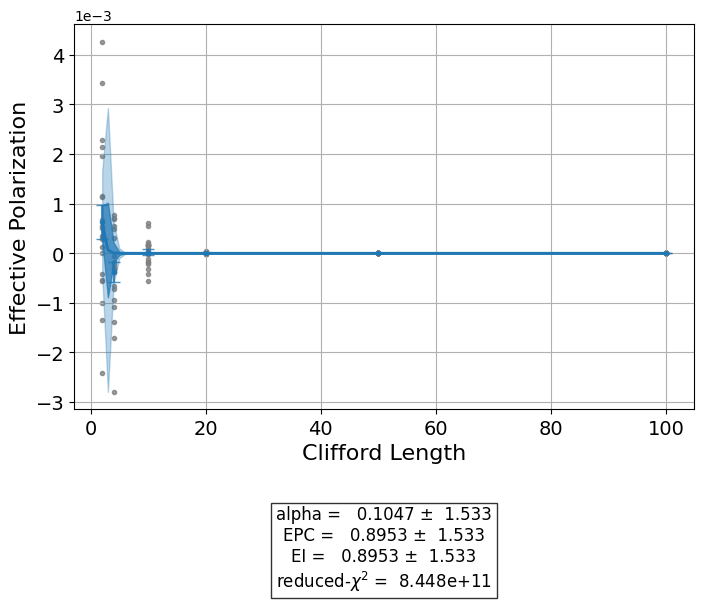

In [8]:
analysis.figure(0)

In [9]:
# Save the MRB plot (extract matplotlib figure from FigureData)
fig = analysis.figure(0).figure
fig.savefig(f'{job_id}/{job_id}_mrb_plot.png', dpi=300, bbox_inches='tight')

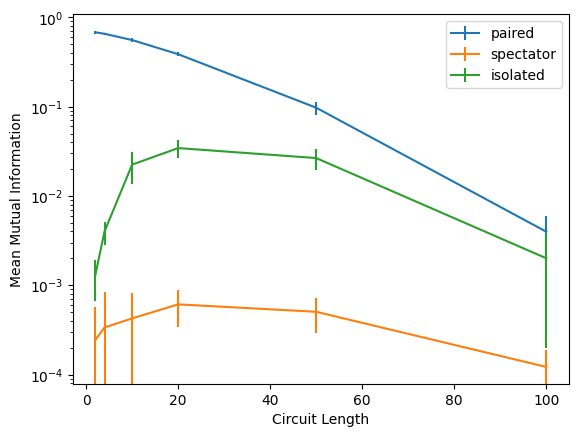

In [6]:
qa = QuantumAwesomeness(exp.backend.coupling_map)
mi = qa.mutual_info(rb_data.data())
mmi = qa.mean_mutual_info(rb_data.data(), exp._pairs)

ys = [[[] for _ in range(6)] for _ in range(3)]
yerrs = [[],[],[]]

for p, pairtype in enumerate(['paired', 'unpaired', 'singles']):
    for j, m in enumerate(mmi[pairtype]):
        # m can be array-like; avoid ambiguous truth-value by checking element-wise NaNs
        m_arr = np.asarray(m)
        # skip if all entries are NaN
        if np.all(np.isnan(m_arr)):
            continue
        # use the mean of the available values (ignoring NaNs) as the representative scalar
        val = np.nanmean(m_arr)
        ys[p][j % 6].append(val)

    for j in range(6):
        if len(ys[p][j]) == 0:
            # no data for this bin -> keep a placeholder (nan) and zero error
            yerrs[p].append(0.0)
            ys[p][j] = np.nan
        else:
            yerrs[p].append(np.std(ys[p][j]))
            ys[p][j] = np.mean(ys[p][j])

plt.errorbar(lengths,ys[0],yerr=yerrs[0],label='paired')
plt.errorbar(lengths,ys[1],yerr=yerrs[1],label='spectator')
plt.errorbar(lengths,ys[2],yerr=yerrs[2],label='isolated')
plt.yscale('log')
plt.legend()
plt.xlabel('Circuit Length')
plt.ylabel('Mean Mutual Information')
plt.title('')

# Save mmi data to folder
mmi_data = {'lengths': lengths,
               'paired': ys[0],
               'spectator': ys[1],
               'isolated': ys[2],
               'paired_err': yerrs[0],
               'spectator_err': yerrs[1],
               'isolated_err': yerrs[2]}
with open(f'{job_id}/{job_id}_mutual_info_data.json', 'w') as f:
    json.dump(mmi_data, f)

# Save MI plot
fig_mi = plt.gcf()
fig_mi.savefig(f'{job_id}/{job_id}_mutual_info_plot.png', dpi=300, bbox_inches='tight')

In [7]:
# count ops before transpilation
op_counts = exp.circuits()[2].count_ops()
print("Operation counts before transpilation:", op_counts)

# sum one qubit gates and two qubit gates separately
one_q_ops = 0
two_q_ops = 0
for op, count in op_counts.items():
    if op in ['x', 'y', 'z', 'h', 's', 'sdg', 't', 'tdg', 'rx', 'ry', 'rz', 'u1', 'u2', 'u3', 'sx', 'sxdg']:
        one_q_ops += count
    elif op in ['cx', 'cz', 'swap', 'cy', 'ch', 'crz', 'cu1', 'cu3']:
        two_q_ops += count
print(f"One-qubit gates: {one_q_ops}, Two-qubit gates: {two_q_ops}")

# count ops after transpilation (experiment already finished)
op_counts_after = exp._static_trans_circuits[2].count_ops()
print("Operation counts after transpilation:", op_counts_after)
# sum one qubit gates and two qubit gates separately
one_q_ops_after = 0
two_q_ops_after = 0
for op, count in op_counts_after.items():
    if op in ['x', 'y', 'z', 'h', 's', 'sdg', 't', 'tdg', 'rx', 'ry', 'rz', 'u1', 'u2', 'u3', 'sx', 'sxdg']:
        one_q_ops_after += count
    elif op in ['cx', 'cz', 'swap', 'cy', 'ch', 'crz', 'cu1', 'cu3']:
        two_q_ops_after += count
print(f"One-qubit gates after transpilation: {one_q_ops_after}, Two-qubit gates after transpilation: {two_q_ops_after}")

Operation counts before transpilation: OrderedDict({'rz': 1194, 'sx': 837, 'Clifford-1Q(6)': 497, 'Clifford-1Q(18)': 471, 'Clifford-1Q(12)': 453, 'Clifford-1Q(0)': 427, 'cz': 398, 'measure': 156, 'Clifford-1Q(3)': 45, 'Clifford-1Q(5)': 45, 'Clifford-1Q(16)': 36, 'Clifford-1Q(10)': 36, 'Clifford-1Q(21)': 34, 'Clifford-1Q(17)': 34, 'Clifford-1Q(8)': 33, 'Clifford-1Q(2)': 33, 'Clifford-1Q(14)': 32, 'Clifford-1Q(4)': 32, 'Clifford-1Q(22)': 32, 'Clifford-1Q(13)': 30, 'Clifford-1Q(23)': 29, 'Clifford-1Q(9)': 29, 'Clifford-1Q(11)': 29, 'Clifford-1Q(15)': 29, 'Clifford-1Q(20)': 28, 'Clifford-1Q(1)': 24, 'barrier': 22, 'Clifford-1Q(19)': 21, 'Clifford-1Q(7)': 21})
One-qubit gates: 2031, Two-qubit gates: 398
Operation counts after transpilation: OrderedDict({'rz': 2983, 'sx': 1333, 'x': 1022, 'cz': 398, 'measure': 156, 'barrier': 22})
One-qubit gates after transpilation: 5338, Two-qubit gates after transpilation: 398
